## Projeto ETL
### Objetivo: Armazenar os gastos (até o momento) por deputado federal.
1. Obter dos dados
2. Efetuar os ajustes necessarios
3. Armazenar no banco de dados (SQLITE)

### Extração

In [2]:
import pandas as pd
import requests

In [10]:
url = "https://dadosabertos.camara.leg.br/api/v2/deputados?ordem=ASC&ordenarPor=nome"
resultado = requests.get(url)

In [13]:
deputados = pd.DataFrame(resultado.json()['dados'])

In [14]:
deputados.head()

,id,uri,nome,siglaPartido,uriPartido,siglaUf,idLegislatura,urlFoto,email
0,204379,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br
1,220714,https://dadosabertos.camara.leg.br/api/v2/depu...,Adail Filho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AM,57,https://www.camara.leg.br/internet/deputado/ba...,dep.adailfilho@camara.leg.br
2,221328,https://dadosabertos.camara.leg.br/api/v2/depu...,Adilson Barroso,PL,https://dadosabertos.camara.leg.br/api/v2/part...,SP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.adilsonbarroso@camara.leg.br
3,204560,https://dadosabertos.camara.leg.br/api/v2/depu...,Adolfo Viana,PSDB,https://dadosabertos.camara.leg.br/api/v2/part...,BA,57,https://www.camara.leg.br/internet/deputado/ba...,dep.adolfoviana@camara.leg.br
4,204528,https://dadosabertos.camara.leg.br/api/v2/depu...,Adriana Ventura,NOVO,https://dadosabertos.camara.leg.br/api/v2/part...,SP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.adrianaventura@camara.leg.br


In [16]:
deputados.shape

(512, 9)

In [57]:
gastos = []
for id in deputados.id:
    url_despesa = f"https://dadosabertos.camara.leg.br/api/v2/deputados/{id}/despesas?ordem=ASC&ano=2023"
    resposta = requests.get(url_despesa)
    gasto = pd.DataFrame(resposta.json()['dados'])
    gasto['id'] = id
    gastos.append(gasto)


In [59]:
len(gastos[0])

15

In [60]:
gastos[0]

,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,urlDocumento,nomeFornecedor,cnpjCpfFornecedor,valorLiquido,valorGlosa,numRessarcimento,codLote,parcela,id
0,2023,1,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,7509529,Nota Fiscal,0,2023-03-14T00:00:00,315,25000.00,https://www.camara.leg.br/cota-parlamentar/doc...,I. RODRIGUES DE ALMEIDA,26711836000198,25000.00,0.00,,1914633,0,204379
1,2023,1,TELEFONIA,0,Nota Fiscal,0,2023-02-15T00:00:00,7526639,353.70,None,CELULAR FUNCIONAL,00000000000001,353.70,0.00,0,0,0,204379
2,2023,1,TELEFONIA,0,Nota Fiscal,0,2023-02-14T00:00:00,7526961,116.43,None,CELULAR FUNCIONAL,00000000000001,116.43,0.00,0,0,0,204379
3,2023,1,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,7506338,Nota Fiscal,0,2023-02-02T00:00:00,202300000000280,10000.00,https://www.camara.leg.br/cota-parlamentar/doc...,E VIEGAS FERREIRA LTDA,15144822000113,10000.00,0.00,,1912967,0,204379
4,2023,3,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7520851,Nota Fiscal Eletrônica,4,2023-03-28T00:00:00,42,809.60,http://www.camara.leg.br/cota-parlamentar/nota...,EDVALDO FRANCISCO DE OLIVEIRA 49191160120,32373812000179,809.60,0.00,,1921029,0,204379
5,2023,2,COMBUSTÍVEIS E LUBRIFICANTES.,7504667,Nota Fiscal,0,2023-02-23T00:00:00,298420,221.98,https://www.camara.leg.br/cota-parlamentar/doc...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,221.98,0.00,,1915529,0,204379
6,2023,2,COMBUSTÍVEIS E LUBRIFICANTES.,7511136,Nota Fiscal Eletrônica,4,2023-02-28T00:00:00,299904,283.97,http://www.camara.leg.br/cota-parlamentar/nota...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,283.97,0.00,,1915531,0,204379
7,2023,3,COMBUSTÍVEIS E LUBRIFICANTES.,7520880,Nota Fiscal Eletrônica,4,2023-03-20T00:00:00,306504,299.98,http://www.camara.leg.br/cota-parlamentar/nota...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,299.98,0.00,,1921040,0,204379
8,2023,5,COMBUSTÍVEIS E LUBRIFICANTES.,7564652,Nota Fiscal Eletrônica,4,2023-05-31T00:00:00,325363,100.04,http://www.camara.leg.br/cota-parlamentar/nota...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,100.04,0.00,,1945830,0,204379
9,2023,7,COMBUSTÍVEIS E LUBRIFICANTES.,7572166,Nota Fiscal Eletrônica,4,2023-07-05T00:00:00,333570,150.00,http://www.camara.leg.br/cota-parlamentar/nota...,031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEI...,00306597003112,150.00,0.00,,1949433,0,204379


### Transformação

In [61]:
total = pd.concat(gastos)

In [62]:
total.head()

,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,urlDocumento,nomeFornecedor,cnpjCpfFornecedor,valorLiquido,valorGlosa,numRessarcimento,codLote,parcela,id
0,2023.0,1.0,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,7509529,Nota Fiscal,0.0,2023-03-14T00:00:00,315,25000.00,https://www.camara.leg.br/cota-parlamentar/doc...,I. RODRIGUES DE ALMEIDA,26711836000198,25000.00,0.0,,1914633.0,0.0,204379
1,2023.0,1.0,TELEFONIA,0,Nota Fiscal,0.0,2023-02-15T00:00:00,7526639,353.70,None,CELULAR FUNCIONAL,00000000000001,353.70,0.0,0,0.0,0.0,204379
2,2023.0,1.0,TELEFONIA,0,Nota Fiscal,0.0,2023-02-14T00:00:00,7526961,116.43,None,CELULAR FUNCIONAL,00000000000001,116.43,0.0,0,0.0,0.0,204379
3,2023.0,1.0,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,7506338,Nota Fiscal,0.0,2023-02-02T00:00:00,202300000000280,10000.00,https://www.camara.leg.br/cota-parlamentar/doc...,E VIEGAS FERREIRA LTDA,15144822000113,10000.00,0.0,,1912967.0,0.0,204379
4,2023.0,3.0,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7520851,Nota Fiscal Eletrônica,4.0,2023-03-28T00:00:00,42,809.60,http://www.camara.leg.br/cota-parlamentar/nota...,EDVALDO FRANCISCO DE OLIVEIRA 49191160120,32373812000179,809.60,0.0,,1921029.0,0.0,204379


In [63]:
# A base possui valores nulos ou ausentes?
total.isnull().sum()

ano                    0
mes                    0
tipoDespesa            0
codDocumento           0
tipoDocumento          0
codTipoDocumento       0
dataDocumento          0
numDocumento           0
valorDocumento         0
urlDocumento         374
nomeFornecedor         0
cnpjCpfFornecedor      0
valorLiquido           0
valorGlosa             0
numRessarcimento       0
codLote                0
parcela                0
id                     0
dtype: int64

In [64]:
del total['urlDocumento']

In [65]:
total.head()

,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,nomeFornecedor,cnpjCpfFornecedor,valorLiquido,valorGlosa,numRessarcimento,codLote,parcela,id
0,2023.0,1.0,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,7509529,Nota Fiscal,0.0,2023-03-14T00:00:00,315,25000.00,I. RODRIGUES DE ALMEIDA,26711836000198,25000.00,0.0,,1914633.0,0.0,204379
1,2023.0,1.0,TELEFONIA,0,Nota Fiscal,0.0,2023-02-15T00:00:00,7526639,353.70,CELULAR FUNCIONAL,00000000000001,353.70,0.0,0,0.0,0.0,204379
2,2023.0,1.0,TELEFONIA,0,Nota Fiscal,0.0,2023-02-14T00:00:00,7526961,116.43,CELULAR FUNCIONAL,00000000000001,116.43,0.0,0,0.0,0.0,204379
3,2023.0,1.0,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,7506338,Nota Fiscal,0.0,2023-02-02T00:00:00,202300000000280,10000.00,E VIEGAS FERREIRA LTDA,15144822000113,10000.00,0.0,,1912967.0,0.0,204379
4,2023.0,3.0,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7520851,Nota Fiscal Eletrônica,4.0,2023-03-28T00:00:00,42,809.60,EDVALDO FRANCISCO DE OLIVEIRA 49191160120,32373812000179,809.60,0.0,,1921029.0,0.0,204379


In [67]:
total.numRessarcimento.value_counts()

numRessarcimento
     6844
0     263
Name: count, dtype: int64

In [68]:
total.shape

(7107, 17)

In [69]:
del total['numRessarcimento']

In [70]:
total.head()

,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,nomeFornecedor,cnpjCpfFornecedor,valorLiquido,valorGlosa,codLote,parcela,id
0,2023.0,1.0,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,7509529,Nota Fiscal,0.0,2023-03-14T00:00:00,315,25000.00,I. RODRIGUES DE ALMEIDA,26711836000198,25000.00,0.0,1914633.0,0.0,204379
1,2023.0,1.0,TELEFONIA,0,Nota Fiscal,0.0,2023-02-15T00:00:00,7526639,353.70,CELULAR FUNCIONAL,00000000000001,353.70,0.0,0.0,0.0,204379
2,2023.0,1.0,TELEFONIA,0,Nota Fiscal,0.0,2023-02-14T00:00:00,7526961,116.43,CELULAR FUNCIONAL,00000000000001,116.43,0.0,0.0,0.0,204379
3,2023.0,1.0,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,7506338,Nota Fiscal,0.0,2023-02-02T00:00:00,202300000000280,10000.00,E VIEGAS FERREIRA LTDA,15144822000113,10000.00,0.0,1912967.0,0.0,204379
4,2023.0,3.0,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7520851,Nota Fiscal Eletrônica,4.0,2023-03-28T00:00:00,42,809.60,EDVALDO FRANCISCO DE OLIVEIRA 49191160120,32373812000179,809.60,0.0,1921029.0,0.0,204379


In [72]:
# Verificar se há dados duplicados!

print(total.shape)
total.drop_duplicates()
print(total.shape)

(7107, 16)
(7107, 16)


In [73]:
# Verificar se o python entendeu os valores da base como numericos

total.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7107 entries, 0 to 14
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ano                7107 non-null   float64
 1   mes                7107 non-null   float64
 2   tipoDespesa        7107 non-null   object 
 3   codDocumento       7107 non-null   object 
 4   tipoDocumento      7107 non-null   object 
 5   codTipoDocumento   7107 non-null   float64
 6   dataDocumento      7107 non-null   object 
 7   numDocumento       7107 non-null   object 
 8   valorDocumento     7107 non-null   float64
 9   nomeFornecedor     7107 non-null   object 
 10  cnpjCpfFornecedor  7107 non-null   object 
 11  valorLiquido       7107 non-null   float64
 12  valorGlosa         7107 non-null   float64
 13  codLote            7107 non-null   float64
 14  parcela            7107 non-null   float64
 15  id                 7107 non-null   int64  
dtypes: float64(8), int64(1), object

In [75]:
# Agora já é possivel ter uma visão sumarizada dos meus dados
# Valor Min, Valor Max, Valor Med, Etc

total.describe()

,ano,mes,codTipoDocumento,valorDocumento,valorLiquido,valorGlosa,codLote,parcela,id
count,7107.0,7107.000000,7107.000000,7107.000000,7107.000000,7107.000000,7.107000e+03,7107.000000,7107.000000
mean,2023.0,6.263262,1.142676,1892.836254,1876.459932,14.994528,1.879299e+06,0.000704,181384.828057
std,0.0,3.430104,1.569092,4531.895776,4512.464412,242.705646,3.695759e+05,0.026517,48167.564531
min,2023.0,1.000000,0.000000,-1875.620000,-1875.620000,0.000000,0.000000e+00,0.000000,62881.000000
25%,2023.0,3.000000,0.000000,200.010000,200.000000,0.000000,1.922627e+06,0.000000,160591.000000
50%,2023.0,6.000000,0.000000,483.120000,476.620000,0.000000,1.947563e+06,0.000000,204431.000000
75%,2023.0,9.000000,1.000000,1608.800000,1545.000000,0.000000,1.975792e+06,0.000000,220582.000000
max,2023.0,12.000000,4.000000,164900.000000,164900.000000,14050.000000,2.023151e+06,1.000000,227310.000000


In [79]:
# Verificar divergencias nos nomes dos fornecedores

total.nomeFornecedor.value_counts().head(20)

nomeFornecedor
AMORETTO CAFES EXPRESSO LTDA                                     393
CEMIG DISTRIBUIÇÃO S.A.                                          204
WMS COMERCIO DE ARTIGOS DE PAPELARIA LTDA-ME                     198
CELULAR FUNCIONAL                                                195
031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA         168
BROADBRASIL LTDA                                                 132
Companhia Energética de Pernambuco                               109
COMPANHIA DE ELETRICIDADE DO ESTADO DA BAHIA                      99
063 - 311 SUL - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA            87
CEEE - Companhia Estadual de Distribuição de Energia Elétrica     77
Copel Distribuição S.A.                                           75
BROAD BRASIL LTDA                                                 70
CLARO NXT TELECOMUNICAÇÕES S.A.                                   60
ENEL - COMPANHIA DE ENERGIA ELÉTRICA                              58
EMIDIO SOUTO PEREIR

In [84]:
# Realizada limpeza, substituindo dados digitados incorretamente.
[str(fornecedor).upper().replace("S.A.","S.A").replace("S/A","S.A").replace("SA","S.A").replace("S. A.","S.A") for fornecedor in total.nomeFornecedor]

['I. RODRIGUES DE ALMEIDA',
 'CELULAR FUNCIONAL',
 'CELULAR FUNCIONAL',
 'E VIEGAS FERREIRA LTDA',
 'EDVALDO FRANCISCO DE OLIVEIRA 49191160120',
 '031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 '031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 '031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 '031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 '031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 '031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 '031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 '031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 '031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 '031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 'WMS COMERCIO DE ARTIGOS DE PAPELARIA LTDA-ME',
 '045 - QL 02 - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 '050 - QI 28 - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 '063 - 311 SUL - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA',
 '063 - 311 SUL - CASCO

In [85]:
#armazenando a informação no dataframe do nome do fornecedor
total.nomeFornecedor = [str(fornecedor).upper().replace("S.A.","S.A").replace("S/A","S.A").replace("SA","S.A").replace("S. A.","S.A") for fornecedor in total.nomeFornecedor]

In [87]:
total.nomeFornecedor.value_counts().head(20)

nomeFornecedor
AMORETTO CAFES EXPRESSO LTDA                                     393
CEMIG DISTRIBUIÇÃO S.A                                           204
WMS COMERCIO DE ARTIGOS DE PAPELARIA LTDA-ME                     198
CELULAR FUNCIONAL                                                195
031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA         168
BROADBRASIL LTDA                                                 132
CLARO NXT TELECOMUNICAÇÕES S.A                                   128
COMPANHIA ENERGÉTICA DE PERNAMBUCO                               109
COMPANHIA DE ELETRICIDADE DO ESTADO DA BAHIA                      99
063 - 311 SUL - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA            87
CEEE - COMPANHIA ESTADUAL DE DISTRIBUIÇÃO DE ENERGIA ELÉTRICA     77
COPEL DISTRIBUIÇÃO S.A                                            75
BROAD BRASIL LTDA                                                 70
ENEL - COMPANHIA DE ENERGIA ELÉTRICA                              58
EMIDIO SOUTO PEREIR

### Load (Carga)

In [88]:
from sqlalchemy import create_engine

In [89]:
engine = create_engine('sqlite:///dados_abertos.bd')

In [90]:
deputados.to_sql('deputados', engine)

512

In [91]:
total.to_sql('despesas_total', engine)

7107

### Análise

In [93]:
total = pd.read_sql("select * from despesas_total;", engine)
total.head()

,index,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,nomeFornecedor,cnpjCpfFornecedor,valorLiquido,valorGlosa,codLote,parcela,id
0,0,2023.0,1.0,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,7509529,Nota Fiscal,0.0,2023-03-14T00:00:00,315,25000.00,I. RODRIGUES DE ALMEIDA,26711836000198,25000.00,0.0,1914633.0,0.0,204379
1,1,2023.0,1.0,TELEFONIA,0,Nota Fiscal,0.0,2023-02-15T00:00:00,7526639,353.70,CELULAR FUNCIONAL,00000000000001,353.70,0.0,0.0,0.0,204379
2,2,2023.0,1.0,TELEFONIA,0,Nota Fiscal,0.0,2023-02-14T00:00:00,7526961,116.43,CELULAR FUNCIONAL,00000000000001,116.43,0.0,0.0,0.0,204379
3,3,2023.0,1.0,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,7506338,Nota Fiscal,0.0,2023-02-02T00:00:00,202300000000280,10000.00,E VIEGAS FERREIRA LTDA,15144822000113,10000.00,0.0,1912967.0,0.0,204379
4,4,2023.0,3.0,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7520851,Nota Fiscal Eletrônica,4.0,2023-03-28T00:00:00,42,809.60,EDVALDO FRANCISCO DE OLIVEIRA 49191160120,32373812000179,809.60,0.0,1921029.0,0.0,204379


In [94]:
deputados = pd.read_sql("select *from deputados", engine)
deputados.head()

,index,id,uri,nome,siglaPartido,uriPartido,siglaUf,idLegislatura,urlFoto,email
0,0,204379,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br
1,1,220714,https://dadosabertos.camara.leg.br/api/v2/depu...,Adail Filho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AM,57,https://www.camara.leg.br/internet/deputado/ba...,dep.adailfilho@camara.leg.br
2,2,221328,https://dadosabertos.camara.leg.br/api/v2/depu...,Adilson Barroso,PL,https://dadosabertos.camara.leg.br/api/v2/part...,SP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.adilsonbarroso@camara.leg.br
3,3,204560,https://dadosabertos.camara.leg.br/api/v2/depu...,Adolfo Viana,PSDB,https://dadosabertos.camara.leg.br/api/v2/part...,BA,57,https://www.camara.leg.br/internet/deputado/ba...,dep.adolfoviana@camara.leg.br
4,4,204528,https://dadosabertos.camara.leg.br/api/v2/depu...,Adriana Ventura,NOVO,https://dadosabertos.camara.leg.br/api/v2/part...,SP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.adrianaventura@camara.leg.br


In [104]:
total.head()

,index_x,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,...,email_x,index,uri_y,nome_y,siglaPartido_y,uriPartido_y,siglaUf_y,idLegislatura_y,urlFoto_y,email_y
0,0,2023.0,1.0,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,7509529,Nota Fiscal,0.0,2023-03-14T00:00:00,315,25000.00,...,dep.acaciofavacho@camara.leg.br,0,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br
1,1,2023.0,1.0,TELEFONIA,0,Nota Fiscal,0.0,2023-02-15T00:00:00,7526639,353.70,...,dep.acaciofavacho@camara.leg.br,0,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br
2,2,2023.0,1.0,TELEFONIA,0,Nota Fiscal,0.0,2023-02-14T00:00:00,7526961,116.43,...,dep.acaciofavacho@camara.leg.br,0,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br
3,3,2023.0,1.0,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,7506338,Nota Fiscal,0.0,2023-02-02T00:00:00,202300000000280,10000.00,...,dep.acaciofavacho@camara.leg.br,0,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br
4,4,2023.0,3.0,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7520851,Nota Fiscal Eletrônica,4.0,2023-03-28T00:00:00,42,809.60,...,dep.acaciofavacho@camara.leg.br,0,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,MDB,https://dadosabertos.camara.leg.br/api/v2/part...,AP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.acaciofavacho@camara.leg.br


In [113]:
total = total.rename(columns={'nome_y':'nome_deputado'})
gastos_deputados = total.groupby(['nome_deputado']).sum()[['valorDocumento','valorLiquido']]

In [115]:
#Ordenando os gastos pelo valor do documento
gastos_deputados = gastos_deputados.sort_values('valorDocumento', ascending=False)

In [116]:
#Top 10 Deputados que Mais gastaram
gastos_deputados.head(10)

,valorDocumento,valorLiquido
nome_deputado,,
Eunício Oliveira,426525.79,426525.79
Glaustin da Fokus,332829.10,332829.10
Gustinho Ribeiro,261700.00,261700.00
Hercílio Coelho Diniz,260814.47,260814.47
Delegado Éder Mauro,217381.15,217381.15
Altineu Côrtes,192900.00,192900.00
Renilce Nicodemos,186563.08,185992.00
Pedro Paulo,184059.81,183071.21
Professor Alcides,170796.06,168755.86


In [117]:
#Top 10 Deputados que Menos gastaram
gastos_deputados.tail(10)

,valorDocumento,valorLiquido
nome_deputado,,
Guilherme Derrite,1638.00,1638.00
Romero Rodrigues,1619.61,1513.72
Flávio Nogueira,1542.28,1526.48
Sargento Fahur,1480.01,1472.45
Paulo Litro,970.06,970.06
Ricardo Barros,830.24,830.24
Hildo Rocha,376.45,376.45
Professora Marcivania,117.90,117.90
André Abdon,44.09,44.09


In [119]:
#Verificando alguns Gráficos!
%matplotlib inline

<Axes: xlabel='nomeFornecedor'>

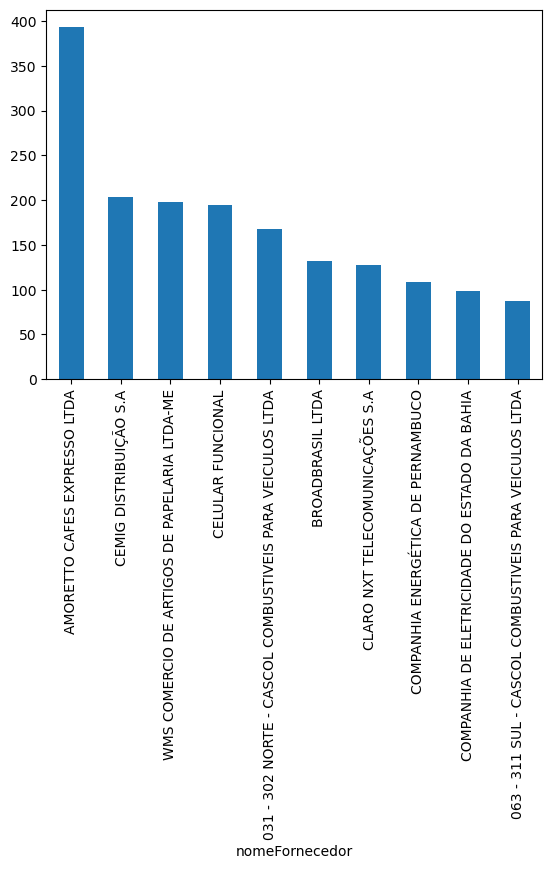

In [122]:
total.nomeFornecedor.value_counts()[:10].plot(kind="bar")